# Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-supervised-learning/01-linear-regression/notes.ipynb)

*The first concrete algorithm — fitting a straight line to data, and the machinery (cost function, gradient
descent, R²) that makes "fitting" a precise, repeatable process instead of a guess. Covers 4 lectures' worth of
ground: the basic model, multivariate regression and preprocessing, model diagnostics, and polynomial regression.*


## 1. The idea, and the running example

- Linear regression fits a straight line (one feature) or a hyperplane (two or more features) between a target and
  its features.
- Guessing a house's price yourself, you'd weigh location, size, age — those are the *features*; the price is the
  *target*.

**The case study we'll use throughout:** a Japanese automaker entering the US market wants to know what actually
drives car prices there.

- *Which* variables matter for predicting a car's price?
- *How well* do those variables explain the price?

**Dataset:** real Cars24 listings — the exact dataset used in class, mirrored on GitHub so this notebook runs
anywhere without needing Google Drive access. Every numeric column (including the one-hot flags) has already been
through a `StandardScaler` — mean 0, standard deviation 1 — which is why the raw numbers below look small and
centered around zero instead of looking like rupee prices or kilometers.

- **Input features (X):** `km_driven`, `mileage`, `engine`, `max_power`, `age`, `year`, `make`, `model`, plus
  one-hot flags `Individual`, `Trustmark Dealer`, `Diesel`, `Electric`, `LPG`, `Petrol`, `Manual`, `5`, `>5`.
- **Target (y):** `selling_price`

**Goal:** build a model that predicts a car's selling price from its features.


### 1.1 Load the data

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

This mirrors exactly what gets pulled via `gdown` in class — hosted on GitHub here instead of a private Google
Drive link, so anyone cloning this repo (and this sandbox, which can't reach Google Drive) can run it too. It's
byte-for-byte the same data: fitting a plain `LinearRegression` on it below reproduces the class's R² and
coefficients to 8 decimal places.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/28101991SUNNY/DSML-Classical-Machine-Learning-1/main/cars24-car-price-clean.csv"
DATA_PATH = "data/cars24-car-price-clean.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)  ## Loading the dataset
df.head()  ## Displaying the first 5 rows of the dataset for quick overview

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


### 1.2 Data notation

Before touching any code, it's worth pinning down the notation class actually uses for this — it shows up in
every formula from here on.

- We have $n$ historical cars — this is the *training data* we already know the price of.
- Each car has $d$ features: $f_1, f_2, f_3, \ldots, f_d$ (`max_power`, `mileage`, `age`, ...).
- $x_i$ — the full feature vector for the $i$-th car (all $d$ features, one row of the table).
- $y_i$ — the actual price of the $i$-th car (what we're trying to predict).

| | $f_1$ | $f_2$ | $\cdots$ | $f_d$ | $y$ |
|---|---|---|---|---|---|
| car 1 | | | | | $y_1$ |
| car 2 | | | | | $y_2$ |
| $\vdots$ | | $x_i$ (this whole row) | | | $\vdots$ |
| car $n$ | | | | | $y_n$ |

So: $x_i \to$ everything we know about car $i$. $y_i \to$ the one number we're trying to learn to predict from it.


### 1.3 The model as a black box

Once we've used the historical data $(x_i, y_i)$ pairs to build a model, using it is simple: hand it a new,
*unseen* car's features and it hands back a predicted price.


```{mermaid}
graph LR
    A["xq<br/>unseen datapoint"] --> B["Model"] --> C["Predicted price<br/>ŷ"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

A model is only useful if its prediction $\hat{y}$ (predicted) lands close to the real $y$ (actual) — that's
the entire game from here on: find a model where $\hat{y} \approx y$ as often and as closely as possible.


### 1.4 A tiny worked example, by hand — no code yet

Before the real Cars24 data, it's worth seeing the whole idea work on numbers small enough to do in your head.
Suppose this is all the historical data we have:

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 1 | 2 | 4 |
| 2 | 2 | 6 |
| 2 | 3 | 7 |
| 3 | 4 | 10 |

**Can you spot the pattern relating $x_1$, $x_2$ to $y$?**

Try a few combinations before reading on — add them, double one and add the other, anything.


**Quick check**

> What's the rule that turns $(x_1, x_2)$ into $y$ for all four rows above?
>
> $y = 2x_1 + x_2$. Check it: $2(1)+2=4$ ✓, $2(2)+2=6$ ✓, $2(2)+3=7$ ✓, $2(3)+4=10$ ✓.


Now here's the real test — two *new* rows we held back:

| $x_1$ | $x_2$ | $y$ (actual) | $\hat{y}$ (from $y=2x_1+x_2$) |
|---|---|---|---|
| 4 | 4 | 12 | $2(4)+4=12$ ✓ |
| 5 | 4 | 14 | $2(5)+4=14$ ✓ |

Both match exactly — the pattern we found on the first 4 rows generalizes perfectly to rows the "model" never saw
while we were figuring out the rule. That's the entire point of a train/test split, just done by hand: **learn the
pattern on some rows, verify it holds on rows you deliberately held back.**

**Your turn:** using $y = 2x_1 + x_2$, what should $y$ be for $x_1=5, x_2=6$?


**Quick check**

> $x_1=5, x_2=6$ → what's $y$?
>
> $y = 2(5) + 6 = 16$.


## 2. Split the data into training and testing sets

Test size is usually 20% of the data. For a small dataset it's common to bump that to 30%, since a 20% slice might
be too little to evaluate on reliably. `random_state` fixes the random seed, so the split is reproducible — run it
again and you get exactly the same train/test division.


In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=40)

### 2.1 Choosing a split ratio, and the one rule you can't break

| Data size | Recommended split | Reasoning |
|---|---|---|
| Small (< 5,000 rows) | 80 / 20 | The model needs more data to learn reliably |
| Large (10,000+ rows) | 70 / 30 | A larger test set gives a more confident evaluation |

**The workflow this split is for:**

```{mermaid}
graph TD
    A["Historical data"] -->|split| B["Train set"]
    A -->|split| C["Test set"]
    B --> D["Model building<br/>algorithm learns patterns"]
    D --> E["Predict on Test set<br/>unseen inputs"]
    E --> F["Evaluate<br/>predicted vs. actual"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style D fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style F fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

> **Golden rule:** never train on test data. The test set must stay unseen throughout training — otherwise
> whatever metric you compute afterward (R², accuracy, anything) is meaningless, because the model is just
> reciting rows it already memorized, not proving it generalizes.

**The split must be random.** If the data is sorted (say, by year), taking the first 80% as train means the model
never sees recent data during training at all. `train_test_split` shuffles by default — that's not an accident,
it's load-bearing.


## 3. The equation of the line

Linear regression tries to fit a straight line through the data. For one feature:

$$
y = mx + c
$$

For multiple features, that becomes a weighted sum:

$$
y = m_1 x_1 + m_2 x_2 + m_3 x_3 + \cdots + c
$$

where $m_1, m_2, m_3, \ldots$ are the coefficients (one per feature) and $c$ is the intercept. "Fitting" the model
means finding the specific values of every $m_i$ and $c$ that make this line match the data as closely as
possible.

In ML terms, the line parameters get renamed: $m$ becomes the **weight** $w$, $c$ becomes the **bias** $b$. The
feature column values are *inputs*, the target column values are *targets* or *labels*. Same equation, different
vocabulary — you'll see both used interchangeably from here on.


**Try it by hand first:** imagine one feature, and two candidate lines for the same 3 points — `(1, 3)`,
`(2, 5)`, `(3, 6)`.

- Line A: $y = 2x + 1$ → predicts 3, 5, 7 for x = 1, 2, 3. Errors: 0, 0, 1.
- Line B: $y = x + 3$ → predicts 4, 5, 6 for x = 1, 2, 3. Errors: 1, 0, 0.

Both lines get 2 out of 3 points exactly right — so which is actually "better" overall? You need a single number
that scores an entire line at once, not just point-by-point right/wrong. That's exactly what the error function
below is for.


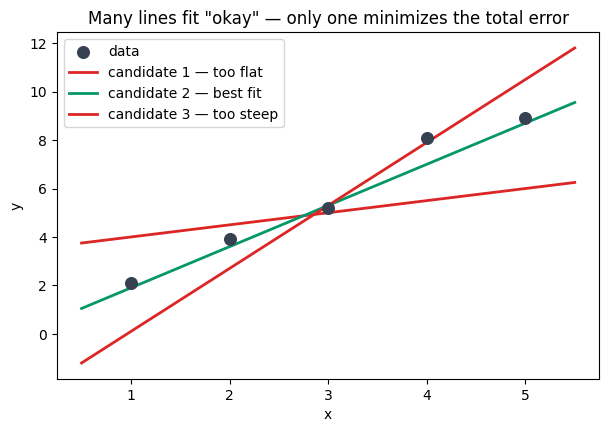

In [4]:
import numpy as np
import matplotlib.pyplot as plt

pts_x = np.array([1, 2, 3, 4, 5])
pts_y = np.array([2.1, 3.9, 5.2, 8.1, 8.9])

xs = np.linspace(0.5, 5.5, 50)
lines = [
    (0.5, 3.5, "#DC2626", "candidate 1 — too flat"),
    (1.7, 0.2, "#059669", "candidate 2 — best fit"),
    (2.6, -2.5, "#DC2626", "candidate 3 — too steep"),
]

plt.figure(figsize=(7, 4.5))
plt.scatter(pts_x, pts_y, color="#374151", zorder=5, s=70, label="data")
for m, c, color, label in lines:
    plt.plot(xs, m * xs + c, color=color, lw=2, label=label)
plt.title("Many lines fit \"okay\" — only one minimizes the total error")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 4. The three ingredients of every ML algorithm

Before diving into the mechanics, it's worth naming the pattern explicitly — because every ML algorithm you'll
ever meet, from this simple line all the way to massive neural networks, is built from exactly three parts:

```{mermaid}
graph LR
    A["🏗️ Model<br/>makes predictions<br/>e.g. y = wx + b"] --> B["📉 Cost Function<br/>measures how wrong<br/>e.g. MSE"]
    B --> C["🔄 Optimizer<br/>adjusts the model<br/>e.g. Gradient Descent"]
    C -.->|repeat| A

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

- **Model** — the equation that turns features into a prediction. For us: $y = mx + c$.
- **Cost function** — a single number scoring how wrong the model currently is. For us: Mean Squared Error.
- **Optimizer** — the algorithm that nudges the model's parameters to make the cost function smaller. For us:
  Gradient Descent.

Once you can name these three pieces for *any* algorithm, you can instantly orient yourself in it — swap out the
model (a neural network instead of a line), the cost function (cross-entropy instead of MSE), or the optimizer
(Adam instead of plain gradient descent), and the loop is exactly the same shape. The rest of this section makes
all three precise for linear regression specifically.


## 5. Prediction, error, and gradient descent

**The training loop, in one sentence:** start with a random guess for $m$ and $c$ → use them to predict
$y_{predicted} = mx + c$ → measure how wrong that guess is → nudge $m$ and $c$ in the direction that makes it
*less* wrong → repeat until it stops improving.

The rest of this section is just making "measure how wrong" and "nudge in the right direction" precise.

### 5.1 Measuring "how wrong" — Mean Squared Error (MSE)

$$
Error = \frac{1}{n} \sum (y - y_{predicted})^2
$$

- Square each point's error before summing — that stops positive and negative misses from canceling out, and
  punishes big misses harder than small ones.
- Averaging over all $n$ points turns "how wrong is this one prediction" into "how wrong is this entire line" —
  a single number you can compare across candidate lines.
- This formula has the same shape as $x^2$ — **convex**, meaning one single lowest point (global minimum) and no
  other dips to get stuck in. That matters for the next step: it's exactly what makes "always walk downhill"
  a strategy that's guaranteed to work.


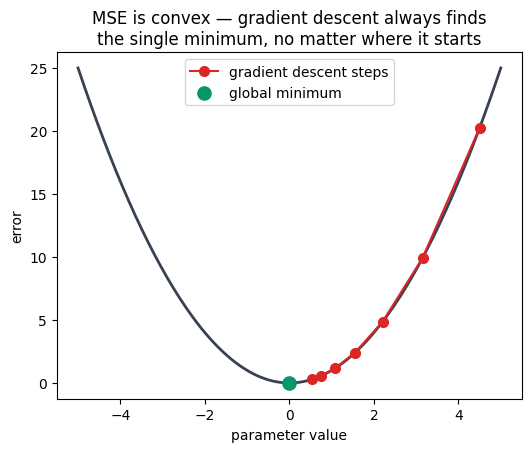

In [5]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-5, 5, 200)
ys = xs**2

# a few steps of gradient descent on f(x) = x^2, starting at x=4.5
path_x = [4.5]
lr = 0.15
for _ in range(6):
    grad = 2 * path_x[-1]
    path_x.append(path_x[-1] - lr * grad)
path_y = [x**2 for x in path_x]

plt.figure(figsize=(6, 4.5))
plt.plot(xs, ys, color="#374151", lw=2)
plt.plot(path_x, path_y, "o-", color="#DC2626", markersize=7, lw=1.5, label="gradient descent steps")
plt.scatter([0], [0], color="#059669", zorder=5, s=90, label="global minimum")
plt.title("MSE is convex — gradient descent always finds\nthe single minimum, no matter where it starts")
plt.xlabel("parameter value"); plt.ylabel("error")
plt.legend()
plt.show()

### 5.2 Walking downhill — gradient descent

The **gradient** is just the slope of the error curve at your current guess. It always points in the direction
the error *increases* fastest — so to make the error smaller, you step the opposite way. That's the entire idea;
everything below is just writing it as a formula.

**General update rule**, for any parameter `x`:

$$
x = x - \text{learning_rate} \cdot \frac{d(Error)}{dx}
$$

- `learning_rate` (also called step size) — how big a step to take each round. Too small and training crawls;
  too large and it overshoots the minimum and can bounce around instead of settling.
- $\frac{d(Error)}{dx}$ — the slope of the error curve at `x`'s current value.

For plain $Error = x^2$, the slope is $2x$, so the rule becomes $x = x - \text{learning_rate} \cdot 2x$ — exactly
the steps the plot above just walked through.

### 5.3 Applying it to our actual parameters, $m$ and $c$

Substitute the real prediction $y_{predicted} = mx + c$ into the error formula:

$$
Error = \frac{1}{n} \sum (y - (mx + c))^2
$$

Now take the slope *separately* for each parameter — how much the error moves if you nudge just $m$ (holding $c$
fixed), and how much it moves if you nudge just $c$ (holding $m$ fixed):

$$
\frac{d(Error)}{dm} = -\frac{2}{n} \sum (y - (mx + c)) \cdot x
\qquad\qquad
\frac{d(Error)}{dc} = -\frac{2}{n} \sum (y - (mx + c))
$$

**Notice the two formulas are identical except for one thing** — the $m$ version has an extra $\cdot\, x$ tacked
on. That's not arbitrary: $m$ multiplies $x$ inside the prediction, so a 1-unit nudge to $m$ moves the prediction
by $x$ units, not 1. $c$ has no such multiplier — nudging it moves the prediction by exactly however much you
nudged it. That's the whole reason the two gradients look different.

**Update rules**, using those two slopes:

$$
m = m - \text{learning_rate} \cdot \frac{d(Error)}{dm}
\qquad\qquad
c = c - \text{learning_rate} \cdot \frac{d(Error)}{dc}
$$

### 5.4 The full loop, one more time

random $m, c$ → predict → measure MSE → compute both gradients → update $m$ and $c$ → repeat until the error
stops meaningfully improving.


**Quick check**

> Why does gradient descent *subtract* the gradient rather than add it?
>
> The gradient points in the direction the error *increases* fastest. To make the error smaller, you move the
> opposite way — hence the minus sign in every update rule above. If you added the gradient instead, you'd be
> deliberately climbing uphill, and the error would grow with every step instead of shrinking.


## 6. R-squared (coefficient of determination)

- Question R² answers: **is this fitted line actually good?**
- How: compare your model's error against the simplest possible baseline — always predicting the average `y`.

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

- $TSS = \sum (y - \bar{y})^2$ — error of the "always predict the mean" baseline.
- $RSS = \sum (y - y_{predicted})^2$ — error of the model you're actually evaluating.


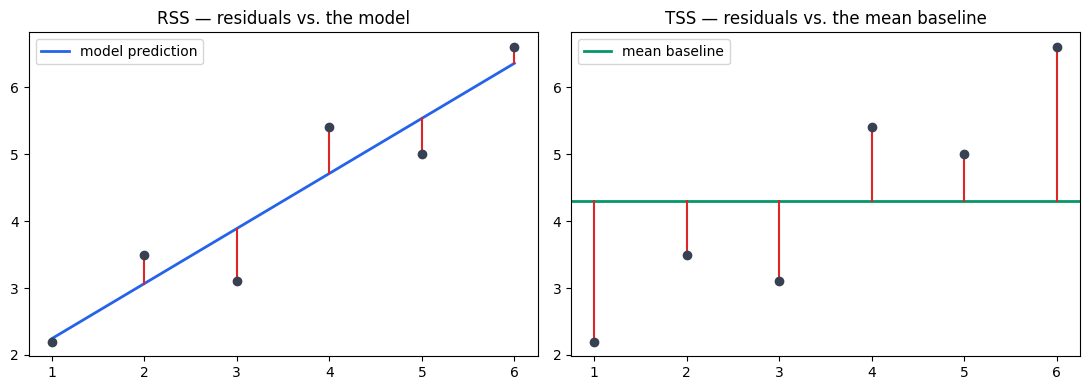

RSS (model)   : 1.63
TSS (baseline): 13.48
R-squared     : 0.879


In [6]:
toy_x = np.array([1, 2, 3, 4, 5, 6])
toy_y = np.array([2.2, 3.5, 3.1, 5.4, 5.0, 6.6])
m_fit, c_fit = np.polyfit(toy_x, toy_y, 1)
toy_pred = m_fit * toy_x + c_fit
toy_mean = np.mean(toy_y)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(toy_x, toy_y, color="#374151", zorder=5)
axes[0].plot(toy_x, toy_pred, color="#2563EB", lw=2, label="model prediction")
for x, y, p in zip(toy_x, toy_y, toy_pred):
    axes[0].plot([x, x], [y, p], color="#DC2626", lw=1.5)
axes[0].set_title("RSS — residuals vs. the model")
axes[0].legend()

axes[1].scatter(toy_x, toy_y, color="#374151", zorder=5)
axes[1].axhline(toy_mean, color="#059669", lw=2, label="mean baseline")
for x, y in zip(toy_x, toy_y):
    axes[1].plot([x, x], [y, toy_mean], color="#DC2626", lw=1.5)
axes[1].set_title("TSS — residuals vs. the mean baseline")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"RSS (model)   : {np.sum((toy_y - toy_pred)**2):.2f}")
print(f"TSS (baseline): {np.sum((toy_y - toy_mean)**2):.2f}")
print(f"R-squared     : {1 - np.sum((toy_y - toy_pred)**2)/np.sum((toy_y - toy_mean)**2):.3f}")

**Reading the number:**
- $R^2 \approx 1$ → excellent fit — model's red lines (left) are much shorter than the baseline's (right).
- $R^2 \approx 0$ → no better than just guessing the average every time.
- $R^2 < 0$ → *worse* than the average-guessing baseline — the chosen $m$, $c$ are genuinely poor.
- Range: $(-\infty, 1]$.

**One line:** R² measures how much of the variance in the data your model explains, versus just predicting the
mean every time.


## 7. Building it from scratch — one feature first

Starting simple: predicting `selling_price` from `max_power` alone. This is the exact function built in class —
notice it scales `x` first (subtracts the mean, divides by the standard deviation), because gradient descent
converges far more reliably when features are on a similar scale.


In [7]:
def regression(x, y, m=1, c=0, learning_rate=0.001, threshold=0.001, max_iter=1000):
    # scaling the data.. will be described below
    x = (x - np.mean(x)) / np.std(x)

    n = len(x)
    prev_error = float('inf')

    for _ in range(max_iter):
        y_predicted = m * x + c
        # error = (1/n) * sum((y - y_predicted) ** 2)
        error = np.mean((y_predicted - y) ** 2)

        if abs(prev_error - error) < threshold:
            break

        # Calculate gradients
        dm = (-2 / n) * sum((y - y_predicted) * x)
        dc = (-2 / n) * sum(y - y_predicted)

        # Update parameters
        m = m - learning_rate * dm
        c = c - learning_rate * dc

        prev_error = error

    return m, c

In [8]:
regression(x=df['max_power'], y=df['selling_price'])

(0.9995407797091496, -1.4925833861837496e-19)

## 8. Generalizing to multiple features

The single-feature version only handles one $m$. Real problems have several features at once — `max_power` and
`mileage` together, say — so the class notebook generalizes it: `m` becomes a weight *vector* `w` (one weight per
feature), and the math becomes matrix operations instead of a single multiply.


In [9]:
import numpy as np
from typing import Tuple, Optional


def regression(
        x: np.ndarray,  # (n_samples, n_features)
        y: np.ndarray,  # (n_samples,)
        w: Optional[np.ndarray] = None,  # (n_features,)
        b: float = 0.0,
        learning_rate: float = 0.01,
        threshold: float = 1e-6,
        max_iter: int = 1000
) -> Tuple[np.ndarray, float]:
    # Ensure numpy arrays
    x = np.asarray(x)
    x = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

    y = np.asarray(y)

    n, n_features = x.shape

    # Initialize weights if not provided
    if w is None:
        w = np.zeros(n_features)

    prev_error = float('inf')

    for _ in range(max_iter):

        # Predictions
        y_predicted = np.dot(x, w) + b

        # Mean Squared Error
        error = np.mean((y_predicted - y) ** 2)

        # Convergence check
        if abs(prev_error - error) < threshold:
            break

        # Gradients
        dw = (2 / n) * np.dot(x.T, (y_predicted - y))
        db = (2 / n) * np.sum(y_predicted - y)

        # Update
        w -= learning_rate * dw
        b -= learning_rate * db

        prev_error = error

    return w, b

In [10]:
x = df[['max_power', 'mileage']].values
y = df['selling_price'].values

regression(x, y)

(array([0.79434556, 0.05793132]), np.float64(-5.550263690735546e-17))

## 9. Scoring the fit with R²

In [11]:
def calculate_r_squared(y_true, y_pred):
    mean = np.mean(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - mean) ** 2)

    return 1 - (rss / tss)

In [12]:
# Train
w, b = regression(x, y)

# Manually scale x the same way
x_scaled = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

# Predict
predicted_car_price = np.dot(x_scaled, w) + b

# R2
r_squared = calculate_r_squared(y, predicted_car_price)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.5967


## 10. Same thing, using scikit-learn
Once you understand what's happening underneath, this is the version you'd actually reach for day to day.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

print(model.coef_)
print(model.intercept_)

[0.80097416 0.0645545 ]
-1.1871485866889763e-16


In [14]:
predicted_car_price = model.predict(x)
r_squared = calculate_r_squared(y, predicted_car_price)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.5967


Only 2 of the 17 available features so far, and already R² ≈ 0.6. What happens if we stop leaving 15 features on
the table? That's where the rest of this notebook picks up.


## 11. Guessing parameters by hand — why we need gradient descent at all

Before reaching for gradient descent, it's worth feeling the pain it solves. Here's the manual process class
actually walked through: pick a `w` and `b`, plot the resulting line against the real data, eyeball how far off
it is, and try again.


In [15]:
def estimate_charges(x, w, b):
    return w * x + b


def try_parameters(w, b, feature="max_power", target="selling_price"):
    x = df[feature]
    y = df[target]
    estimated = estimate_charges(x, w, b)

    plt.figure(figsize=(8, 5))
    order = np.argsort(x.values)
    plt.plot(x.values[order], estimated.values[order], 'r', alpha=0.9, label='estimate')
    plt.scatter(x, y, s=8, alpha=0.5, label='actual')
    plt.xlabel(feature); plt.ylabel(target)
    plt.legend()
    plt.title(f"w={w}, b={b}")
    plt.show()

**First guess — wildly off.** Since our data is already standardized (roughly in the $[-3, 3]$ range), a slope
of 2 and an intercept of 1 overshoots badly:

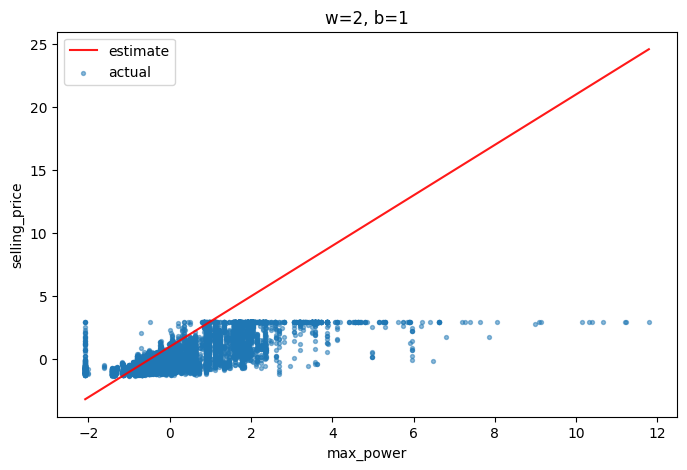

In [16]:
try_parameters(2, 1)

**Second guess — closer, but still not it:**

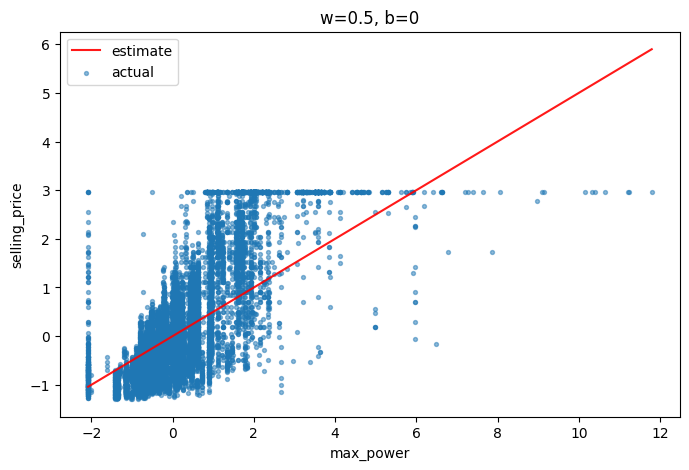

In [17]:
try_parameters(0.5, 0)

**Third guess — getting there, by eye:**

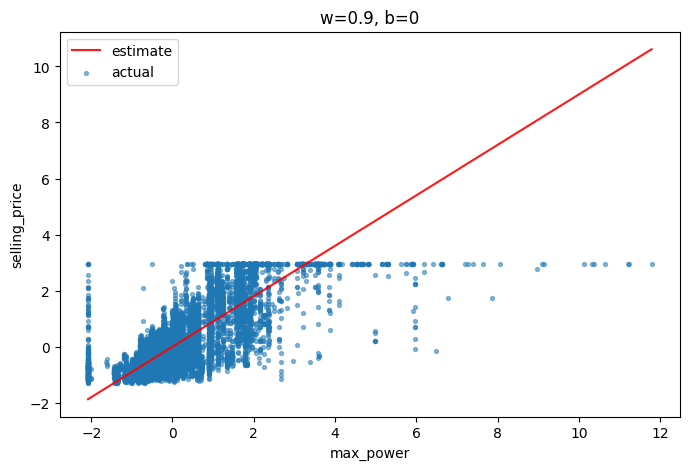

In [18]:
try_parameters(0.9, 0)

> **The problem with manual tuning:** changing `w` and `b` by hand and eyeballing the plot is tedious and
> imprecise — there's no way to tell *how much* better guess 3 is than guess 2 beyond "looks closer." We need a
> number (the cost function) and a systematic way to improve it (the optimizer) — exactly the two ingredients
> Section 4 named, and exactly what gradient descent in Section 5 automates.


## 12. Multivariate Linear Regression — using every feature at once

Time to stop leaving 15 features on the table. With $d$ features, the model equation becomes:

$$
\text{price} = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b
$$


In [19]:
X_all = df[df.columns.drop('selling_price')].to_numpy()
Y_all = df['selling_price'].to_numpy().reshape(-1, 1)

print(X_all.shape, Y_all.shape)

full_model = LinearRegression()
full_model.fit(X_all, Y_all)
print("R-squared, all 17 features:", full_model.score(X_all, Y_all))

(19820, 17) (19820, 1)
R-squared, all 17 features: 0.9421889572026914


Compare that to the ≈0.60 we got out of `max_power` + `mileage` alone in Section 10 — using every available
feature buys a large, real jump in how much of the price variance the model explains.


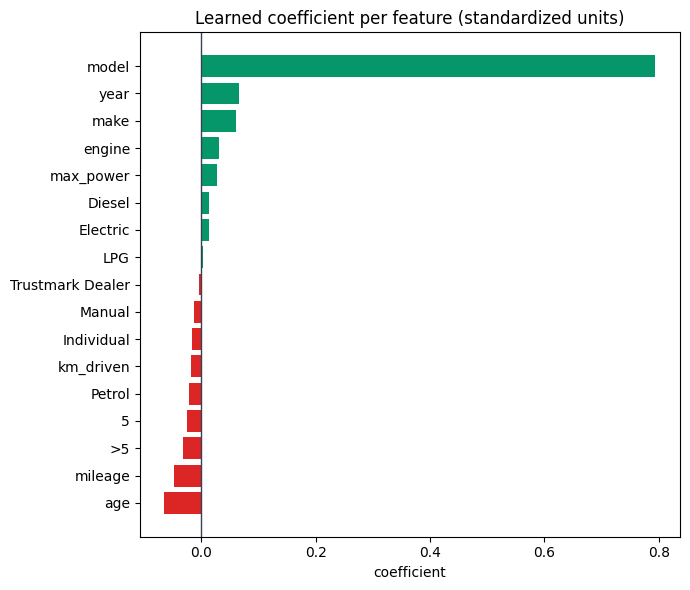

In [20]:
coef_series = pd.Series(full_model.coef_.ravel(), index=df.columns.drop('selling_price')).sort_values()

plt.figure(figsize=(7, 6))
colors = ["#DC2626" if v < 0 else "#059669" for v in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(0, color="#374151", lw=1)
plt.title("Learned coefficient per feature (standardized units)")
plt.xlabel("coefficient")
plt.tight_layout()
plt.show()

### 12.1 Reading the coefficients

Since every feature is on the same standardized scale, the coefficients are directly comparable — the tallest
bars are the strongest predictors. `model` towers over everything else, which matches intuition: which specific
car model you're looking at captures a huge amount of price information (luxury sedan vs. hatchback) that no
other single column fully captures.

**The general rule for reading a coefficient**, using a toy ad-spend example instead of cars:

$$
\hat{y} = 3 + 2 \cdot \text{TV} + 3 \cdot \text{SocialMedia}
$$

- Holding TV spend fixed, a +1 unit increase in Social Media spend → **+3** units of sales.
- Holding Social Media fixed, a +1 unit increase in TV spend → **+2** units of sales.
- Social Media has the stronger effect here — its coefficient has the larger magnitude.

Flip the sign and the story flips too: $\hat{y} = 3 + 2\cdot\text{TV} - 3\cdot\text{SocialMedia}$ would mean more
social spend *decreases* predicted sales (maybe a campaign that backfired).

> **Key rule:** the coefficient's *magnitude* tells you influence strength, its *sign* tells you direction — but
> only when every feature is on the same scale. Comparing raw, unscaled coefficients directly is meaningless
> (a coefficient of 50,000 on a feature measured in single digits can be weaker than a coefficient of 0.001 on a
> feature measured in millions). That's exactly why scaling matters — the next section makes it precise.


## 13. Feature scaling — Standardization vs. Min-Max

Imagine two features in a model: `TV budget` (values in the thousands) and `Social Media budget` (values in
single digits, because it's tracked in millions). Left alone, gradient descent compensates for the mismatch by
picking a tiny weight for TV and a huge weight for Social Media — which makes the *raw* coefficients incomparable
and can slow convergence.

**Two standard fixes:**

| Method | Formula | Result |
|---|---|---|
| Z-score standardization | $(x_i - \mu) / \sigma$ | mean 0, std 1 |
| Min-Max normalization | $(x_i - \min) / (\max - \min)$ | every value in $[0, 1]$ |


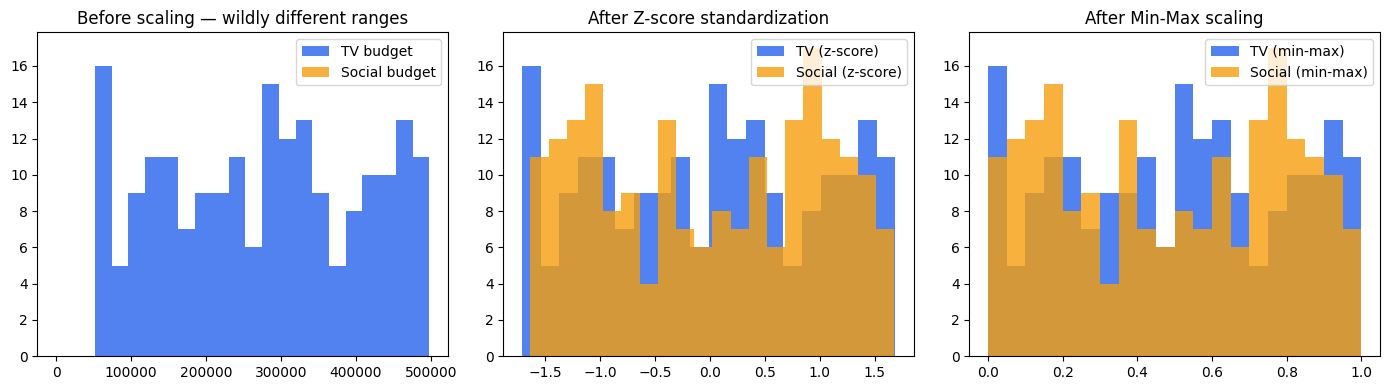

In [21]:
rng = np.random.default_rng(7)
tv_budget = rng.uniform(50_000, 500_000, 200)
social_budget = rng.uniform(1, 30, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(tv_budget, bins=20, color="#2563EB", alpha=0.8, label="TV budget")
axes[0].hist(social_budget, bins=20, color="#F59E0B", alpha=0.8, label="Social budget")
axes[0].set_title("Before scaling — wildly different ranges")
axes[0].legend()

z_tv = (tv_budget - tv_budget.mean()) / tv_budget.std()
z_social = (social_budget - social_budget.mean()) / social_budget.std()
axes[1].hist(z_tv, bins=20, color="#2563EB", alpha=0.8, label="TV (z-score)")
axes[1].hist(z_social, bins=20, color="#F59E0B", alpha=0.8, label="Social (z-score)")
axes[1].set_title("After Z-score standardization")
axes[1].legend()

mm_tv = (tv_budget - tv_budget.min()) / (tv_budget.max() - tv_budget.min())
mm_social = (social_budget - social_budget.min()) / (social_budget.max() - social_budget.min())
axes[2].hist(mm_tv, bins=20, color="#2563EB", alpha=0.8, label="TV (min-max)")
axes[2].hist(mm_social, bins=20, color="#F59E0B", alpha=0.8, label="Social (min-max)")
axes[2].set_title("After Min-Max scaling")
axes[2].legend()

plt.tight_layout()
plt.show()

### 13.1 The outlier problem with Min-Max

Min-Max squeezes everything into $[0, 1]$ by construction — proof: at $x_i = \min$, the result is 0; at
$x_i = \max$, the result is 1; everything else lands in between.

> **Critical limitation:** if a feature has one extreme outlier, that outlier *becomes* the max. Every other,
> perfectly normal value then gets squashed into a tiny band near 0 (e.g. $[0.0, 0.18]$), losing most of the
> real variance in the feature. Z-score standardization is more robust here, since it's built from the mean and
> standard deviation rather than the raw min/max — one outlier moves those far less than it moves the range.

**Rule of thumb:** handle outliers first (Section 15 covers this), then Min-Max if you need a bounded $[0,1]$
range for a specific downstream reason; otherwise Z-score standardization is the safer default.


## 14. Case study: predicting a car's mileage

A full walkthrough of one-hot encoding and missing-value handling, on a different, smaller dataset: the classic
Auto MPG dataset (real cars, 1970s-80s, predicting miles-per-gallon from engine specs).


In [22]:
MPG_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
MPG_PATH = "data/auto-mpg.csv"

if not os.path.exists(MPG_PATH):
    pd.read_csv(MPG_URL).to_csv(MPG_PATH, index=False)

cData = pd.read_csv(MPG_PATH)
cData.shape

(398, 9)

| Feature | Type | Notes |
|---|---|---|
| `mpg` | float | 🎯 target |
| `cylinders` | int | number of cylinders |
| `displacement` | float | engine displacement (cu. in.) |
| `horsepower` | float | has missing values |
| `weight` | int | vehicle weight (lbs) |
| `acceleration` | float | 0-60 mph time (sec) |
| `model_year` | int | two-digit year |
| `origin` | string | `usa` / `europe` / `japan` |
| `name` | string | dropped — not a generalizable feature |


In [23]:
# dropping/ignoring the car name — a string identifier, not a generalizable feature
cData = cData.drop('name', axis=1)
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


### 14.1 One-Hot Encoding

`origin` is categorical: `usa`, `europe`, `japan`. We can't feed strings into a regression model, and coding
them as 1/2/3 would be worse — it would imply an ordering that doesn't exist (the equation would treat `japan`
as having 3× the effect of `usa`, which is nonsense for a category with no natural order).

**The fix — one binary column per category:**

| origin | origin_usa | origin_europe | origin_japan |
|---|---|---|---|
| usa | 1 | 0 | 0 |
| europe | 0 | 1 | 0 |
| japan | 0 | 0 | 1 |

With 3 categories, knowing any 2 columns tells you the 3rd for free (not usa and not europe → must be japan) —
one column is redundant and, left in, causes multicollinearity (more on this in Section 19). Drop one:


In [24]:
cData = pd.get_dummies(cData, columns=['origin'], dtype=int)
X = cData.drop(['mpg', 'origin_europe'], axis=1)
y = cData[['mpg']]
X.columns.tolist()

['cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model_year',
 'origin_japan',
 'origin_usa']

### 14.2 Handling missing values

The classic UCI version of this dataset marks missing horsepower readings with a literal `?` string, which
forces the whole column to be read as text instead of numbers. Our copy already has those as proper `NaN`, so we
can skip straight to detecting and fixing them — but the fix is the same either way.


In [25]:
missing_mask = X['horsepower'].isna()
X[missing_mask]

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
32,4,98.0,NaN,2046,19.0,71,0,1
126,6,200.0,NaN,2875,17.0,74,0,1
330,4,85.0,NaN,1835,17.3,80,0,0
336,4,140.0,NaN,2905,14.3,80,0,1
354,4,100.0,NaN,2320,15.8,81,0,0
374,4,151.0,NaN,3035,20.5,82,0,1


Six rows, out of 398, are missing `horsepower`. Dropping them is an option, but **imputing with the median**
keeps the rows without distorting the distribution — unlike the mean, the median isn't pulled toward outliers or
skew.


In [26]:
median_hp = X['horsepower'].median()
print(f"Median horsepower used for imputation: {median_hp}")
X = X.fillna(X.median(numeric_only=True))
X['horsepower'].isna().sum()

Median horsepower used for imputation: 93.5


np.int64(0)

### 14.3 Fit and evaluate

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

for col, coef in zip(X_train.columns, regression_model.coef_[0]):
    print(f"{col}: {coef:.4f}")
print(f"intercept: {regression_model.intercept_[0]:.4f}")

cylinders: -0.3948
displacement: 0.0289
horsepower: -0.0218
weight: -0.0074
acceleration: 0.0619
model_year: 0.8369
origin_japan: -0.6060
origin_usa: -3.0013
intercept: -18.2835


In [28]:
print("Train R²:", regression_model.score(X_train, y_train))
print("Test R²: ", regression_model.score(X_test, y_test))

Train R²: 0.8141025501610559
Test R²:  0.8433135132808833


**Reading the coefficients:** `model_year` has the strongest positive effect — newer cars get meaningfully
better mileage. `cylinders` and `weight` pull the other way — heavier, bigger-engined cars are less efficient.
`origin_usa` being strongly negative says American cars in this dataset average noticeably lower mpg than the
`europe` baseline we dropped.

> **Healthy sign:** Test R² coming out close to (or even slightly above) Train R² means the model generalizes —
> it isn't overfitting the training rows. If Test R² had collapsed far below Train R², that would be the
> overfitting signature covered in Section 22.


## 15. The impact of outliers on the regression line

The regression line minimizes the *sum of squared* errors — and because errors are squared, one point sitting
far from the rest exerts a wildly disproportionate pull on where the line ends up.


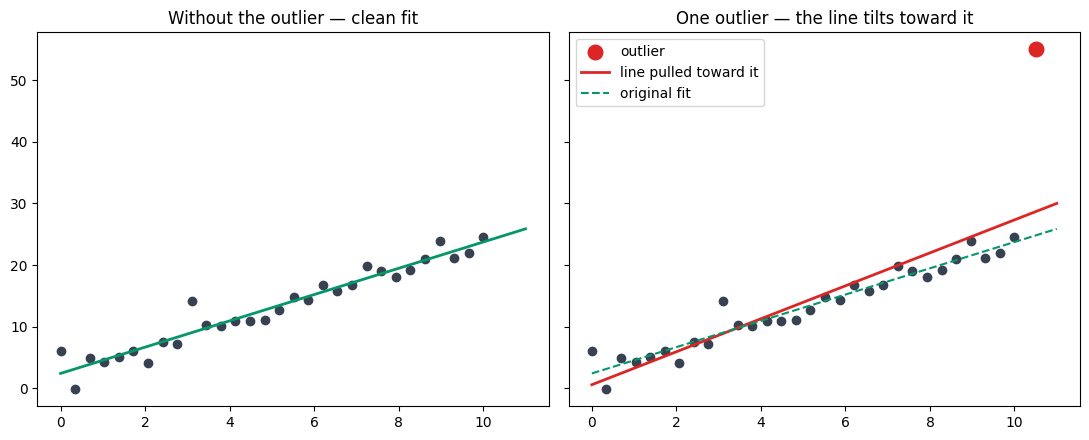

Slope without outlier: 2.13
Slope with outlier:    2.67


In [29]:
rng = np.random.default_rng(3)
clean_x = np.linspace(0, 10, 30)
clean_y = 2 * clean_x + 3 + rng.normal(0, 1.5, size=30)

outlier_x = np.append(clean_x, 10.5)
outlier_y = np.append(clean_y, 55)  # one wildly extreme point

m_clean, c_clean = np.polyfit(clean_x, clean_y, 1)
m_out, c_out = np.polyfit(outlier_x, outlier_y, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

xs = np.linspace(0, 11, 50)
axes[0].scatter(clean_x, clean_y, color="#374151")
axes[0].plot(xs, m_clean * xs + c_clean, color="#059669", lw=2)
axes[0].set_title("Without the outlier — clean fit")

axes[1].scatter(outlier_x[:-1], outlier_y[:-1], color="#374151")
axes[1].scatter([outlier_x[-1]], [outlier_y[-1]], color="#DC2626", s=110, zorder=5, label="outlier")
axes[1].plot(xs, m_out * xs + c_out, color="#DC2626", lw=2, label="line pulled toward it")
axes[1].plot(xs, m_clean * xs + c_clean, color="#059669", lw=1.5, ls="--", label="original fit")
axes[1].set_title("One outlier — the line tilts toward it")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Slope without outlier: {m_clean:.2f}")
print(f"Slope with outlier:    {m_out:.2f}")

Like a rubber band stretched toward a pin, the further the outlier sits from the main cluster, the harder it
drags the line — at the cost of fitting every *other* point worse.

> **Best practice:** always detect and treat outliers before fitting. Common approaches: IQR-based clipping,
> z-score filtering, or plain visual inspection with a box plot.


## 16. R² isn't the whole story — Adjusted R²

**The flaw:** R² can only go up (or stay flat) as you add more features — even features that are pure random
noise. A model with 50 useless features will show a *higher* R² than one with 5 genuinely good ones. Plain R²
alone can't tell a real improvement from padding.

**The fix:**

$$
\text{Adj. } R^2 = 1 - (1 - R^2) \cdot \frac{n - 1}{n - p - 1}
$$

where $n$ is the number of samples and $p$ the number of features. Adding a genuinely useless feature now
*decreases* Adjusted R², because the penalty term grows while $R^2$ barely moves.


In [30]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    df[df.columns.drop('selling_price')], df['selling_price'], test_size=0.2, random_state=2
)

full_model2 = LinearRegression().fit(X_train_all, y_train_all)
r2_test = full_model2.score(X_test_all, y_test_all)

n = len(y_test_all)
p = X_test_all.shape[1]
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

print(f"R² (test):          {r2_test:.4f}")
print(f"Adjusted R² (test): {adj_r2:.4f}")

R² (test):          0.9455
Adjusted R² (test): 0.9453


> **When to use which:** plain R² for a quick sanity check; Adjusted R² whenever you're comparing models with a
> *different* number of features — it's the fairer judge, since it won't reward padding a model with junk
> columns just to nudge the score up.


## 17. Statistical inference with StatsModels

Scikit-learn is built for prediction accuracy. **StatsModels** is built for statistical inference — it hands
back p-values, confidence intervals, and diagnostic tests that scikit-learn doesn't compute at all.

| | Scikit-Learn | StatsModels |
|---|---|---|
| Primary goal | Prediction accuracy | Statistical inference |
| Coefficients | ✅ | ✅ |
| p-values | ❌ | ✅ |
| Confidence intervals | ❌ | ✅ |
| Diagnostic tests | ❌ | ✅ |


In [31]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train_all)  # StatsModels doesn't add an intercept automatically
sm_model = sm.OLS(y_train_all.values, X_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                 1.588e+04
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:00:58   Log-Likelihood:                -7.3180
No. Observations:               15856   AIC:                             48.64
Df Residuals:                   15839   BIC:                             179.0
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             7.664e-05      0.002  

/tmp/ipykernel_1911/1255880531.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  sm_model = sm.OLS(y_train_all.values, X_sm).fit()


**Reading the table:**

| Column | Meaning |
|---|---|
| `coef` | Estimated coefficient for the feature |
| `std err` | Standard error — uncertainty in that estimate |
| `t` | t-statistic: `coef / std err` |
| `P>\|t\|` | p-value — probability of seeing this coefficient if the true effect were zero. Below 0.05 is conventionally "significant" |
| `[0.025 0.975]` | 95% confidence interval for the coefficient |

Notice the printed warning about the condition number being very large — that's StatsModels flagging the exact
same problem the next two sections dig into: strong multicollinearity among the features (in our case, `year`
and `age` are literally the same information, since `age` is derived from `year`).


## 18. The 5 assumptions of Linear Regression

A high R² doesn't automatically mean a *trustworthy* model. Linear Regression's coefficients, p-values, and
confidence intervals are only valid when the data satisfies five assumptions underneath it. Violating them
doesn't always visibly break the model's predictions — but it can silently invalidate everything you'd want to
say *about* those predictions.

| # | Assumption | Severity | What it means |
|---|---|---|---|
| 1 | Linearity | 🔴 Critical | Each feature relates to the target in a straight line |
| 2 | No multicollinearity | 🔴 Critical | Features aren't linearly derivable from each other |
| 3 | Normally distributed errors | 🟠 Important | Residuals follow a bell curve centered at zero |
| 4 | Error independence | 🟠 Important | Residuals show no pattern or correlation with each other |
| 5 | Homoscedasticity | 🟠 Important | Residual spread stays roughly constant across all predictions |

**Assumption 1 in a bit more detail — Linearity.** If the true relationship is a curve (an S-curve, an
exponential, a wave), a straight line structurally cannot capture it, no matter how well you fit `m` and `c`.

- *How to check:* scatter plots of each feature against the target; residual plots — a visible pattern in the
  residuals means linearity is violated.
- *How to fix:* Polynomial Regression (Section 21) — transform the features into higher-order terms so a linear
  model can still fit the (now-linear-in-the-new-features) relationship.
- *Real examples of non-linear relationships:* electricity consumption vs. year (S-curve), sales vs. ad spend
  (diminishing returns), blood pressure vs. BMI.

The rest of this section walks through Assumptions 2 through 5 one at a time, with the actual detection code for
each.


## 19. Multicollinearity and the Variance Inflation Factor (VIF)

**Multicollinearity** happens when one feature can be predicted from the others — e.g. if
$x_2 = 3x_3 + 2x_4$, then $x_2$ carries no information the model doesn't already have from $x_3$ and $x_4$. The
model can no longer isolate $x_2$'s *own* effect, so its coefficient becomes unstable and unreliable.

**In our dataset:** `year` and `age` are almost perfectly correlated — `age` is just `current_year − year`.
Including both leaves the model unable to tell which one is actually driving the price.

**Symptoms:** unexpectedly large coefficients (or the wrong sign), high standard errors despite a good overall
R², a large condition number in the StatsModels summary (we just saw one).

### 19.1 How VIF works

For each feature $x_j$: treat it as the *target*, fit a regression predicting it from every other feature, and
look at that regression's $R^2_j$ — a high $R^2_j$ means $x_j$ is well-explained by the rest, i.e. redundant.

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

| VIF | Interpretation | Action |
|---|---|---|
| > 10 | Very high multicollinearity | Remove |
| 5 – 10 | High | Consider removing |
| < 5 | Acceptable | Keep |


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_tr_vif, X_te_vif, y_tr_vif, y_te_vif = train_test_split(
    df[df.columns.drop('selling_price')], df['selling_price'], test_size=0.2, random_state=2
)

vif = pd.DataFrame()
vif['Features'] = X_tr_vif.columns
vif['VIF'] = [variance_inflation_factor(X_tr_vif.values, i) for i in range(X_tr_vif.shape[1])]
vif = vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif

/tmp/ipykernel_1911/1300618196.py:9: UserWarning: The design matrix is poorly conditioned (condition number=5.05e+15). VIF calculations may be numerically unstable.
  vif['VIF'] = [variance_inflation_factor(X_tr_vif.values, i) for i in range(X_tr_vif.shape[1])]
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stat

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,Features,VIF
0,year,1.000800e+15
1,age,1.000800e+15
2,Petrol,1.829670e+01
3,Diesel,1.729778e+01
4,>5,1.304478e+01
5,5,1.175045e+01
6,engine,6.256598e+00
7,model,5.777104e+00
8,max_power,4.996432e+00
9,mileage,3.221178e+00


`year` (and its twin `age`) come back with an enormous VIF — the warnings printed above ("rank-deficient",
"poorly conditioned") *are* the multicollinearity: statsmodels is telling us the exact same thing the VIF numbers
are, from a different angle. That perfect $\text{corr}(\text{year}, \text{age}) = -1$ is the textbook case this
whole diagnostic exists to catch.

### 19.2 Iterative elimination

Remove the worst offender, recompute VIF on what's left, repeat — until every remaining feature is under the
threshold, or removing more would cost too much Adjusted R².


In [33]:
import warnings

cols = list(X_tr_vif.columns)
feats_removed = []
vif_threshold = 5
adj_r2_threshold = 0.85

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    while True:
        X_current = X_tr_vif[cols]
        vifs = [variance_inflation_factor(X_current.values, i) for i in range(X_current.shape[1])]
        vif_now = pd.DataFrame({'Features': cols, 'VIF': vifs}).sort_values('VIF', ascending=False).reset_index(drop=True)

        X_sm_current = sm.add_constant(X_current)
        current_fit = sm.OLS(y_tr_vif.values, X_sm_current).fit()

        if vif_now.iloc[0]['VIF'] < vif_threshold or current_fit.rsquared_adj < adj_r2_threshold:
            break

        feats_removed.append(vif_now.iloc[0]['Features'])
        cols = [c for c in cols if c != vif_now.iloc[0]['Features']]

print("Features removed:", feats_removed)
print("Final Adjusted R²:", current_fit.rsquared_adj)
vif_now

Features removed: ['year', 'Petrol', '>5', 'engine', 'model']
Final Adjusted R²: 0.8318553555450335


,Features,VIF
0,max_power,2.713200
1,make,2.330356
2,mileage,2.242645
3,Manual,1.659314
4,Diesel,1.528390
5,5,1.451266
6,age,1.313376
7,km_driven,1.196521
8,Electric,1.172746
9,Individual,1.081879


✅ We went from 17 features down to a smaller, decorrelated set with every VIF comfortably under 5, and barely
gave up any Adjusted R² in the process — the redundant features weren't adding real predictive power, just
noise in the coefficients.


## 20. Residual diagnostics — normality, independence, homoscedasticity

The remaining three assumptions are all checked by looking at the model's *residuals* (errors), not its
predictions directly.

### 20.1 Assumption 3 — errors should be normally distributed

Well-specified residuals should look like a bell curve centered at zero. If they don't, it's often a sign of
outliers, a skewed target, or a genuinely misspecified (e.g. non-linear) model.


/tmp/ipykernel_1911/193856747.py:2: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  sm_model_full = sm.OLS(y_tr_vif.values, X_sm_full).fit()


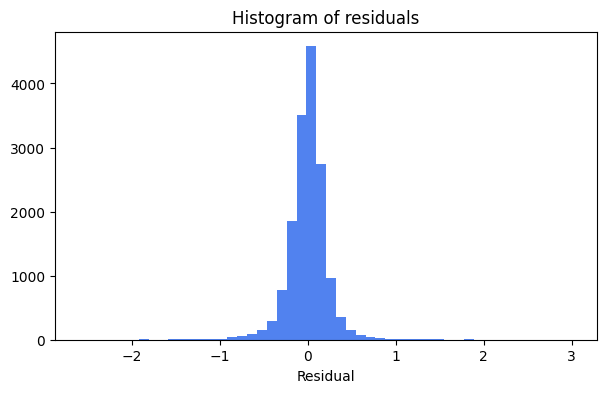

In [34]:
X_sm_full = sm.add_constant(X_tr_vif)
sm_model_full = sm.OLS(y_tr_vif.values, X_sm_full).fit()

y_hat = sm_model_full.predict(X_sm_full)
errors = y_hat - y_tr_vif.values

plt.figure(figsize=(7, 4))
plt.hist(errors, bins=50, color="#2563EB", alpha=0.8)
plt.xlabel("Residual"); plt.title("Histogram of residuals")
plt.show()

In [35]:
from scipy import stats

shapiro_sample = errors if len(errors) <= 5000 else np.random.default_rng(0).choice(errors, 5000, replace=False)
shapiro_result = stats.shapiro(shapiro_sample)
print("Shapiro-Wilk statistic:", shapiro_result.statistic)

Shapiro-Wilk statistic: 0.8434437665327403


| Statistic | Interpretation |
|---|---|
| close to 1.0 | strong normality |
| 0.85 – 0.95 | moderate normality — acceptable on large datasets |
| below 0.8 | significant departure — investigate outliers |

### 20.2 Assumption 4 — errors should be independent

A scatter of residuals vs. the target should show no visible pattern — just random scatter around zero. This is
mostly a time-series concern (errors at time $t$ correlating with errors at $t-1$, called autocorrelation); for
a cross-sectional dataset like ours it's rarely an issue.

The **Durbin-Watson statistic**, printed in every StatsModels summary, tests exactly this — values near 2.0 mean
no autocorrelation; values near 0 or 4 signal a problem.


In [36]:
print("Durbin-Watson:", sm.stats.stattools.durbin_watson(sm_model_full.resid))

Durbin-Watson: 2.002825256244877


### 20.3 Assumption 5 — homoscedasticity (constant error variance)

The residuals' spread should stay roughly constant across all predicted values. Its opposite,
**heteroscedasticity**, shows up as a cone shape — errors fanning out (or in) as predictions grow.


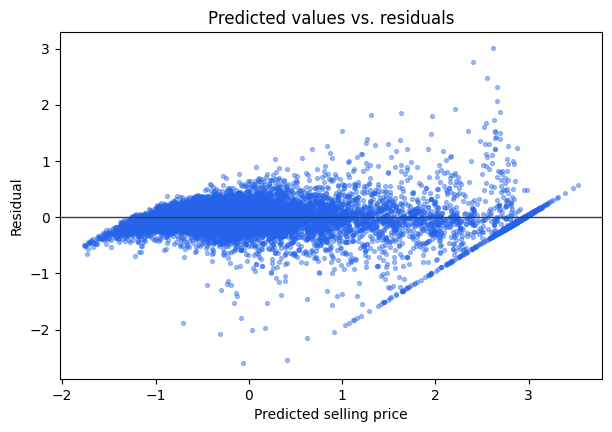

In [37]:
plt.figure(figsize=(7, 4.5))
plt.scatter(y_hat, errors, s=8, alpha=0.4, color="#2563EB")
plt.axhline(0, color="#374151", lw=1)
plt.xlabel("Predicted selling price"); plt.ylabel("Residual")
plt.title("Predicted values vs. residuals")
plt.show()

In [38]:
import statsmodels.stats.api as sms

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gq_stat, gq_pvalue, _ = sms.het_goldfeldquandt(y_tr_vif, X_sm_full)
print(f"Goldfeld-Quandt F statistic: {gq_stat:.3f}")
print(f"Goldfeld-Quandt p-value:     {gq_pvalue:.3f}")

Goldfeld-Quandt F statistic: 0.991
Goldfeld-Quandt p-value:     0.656


The Goldfeld-Quandt test formally compares residual variance in the lower half of the data vs. the upper half.
An F-statistic near 1 with a p-value above 0.05 means we fail to reject the null of equal variance —
homoscedasticity holds.

> **If you do find heteroscedasticity:** transform the target (`log(y)`, `sqrt(y)`, or Box-Cox), remove outliers
> that are inflating variance in one region, or move to weighted least squares regression.


## 21. Polynomial Regression — when the data isn't a line

When Assumption 1 (linearity) fails — the true relationship visibly curves — the fix isn't a different
algorithm, it's different *features*. Real non-linear examples: electricity/energy consumption vs. year
(S-curve), seasonal sales vs. month (sinusoidal), blood pressure vs. BMI.

**The idea:** instead of feeding the model raw $x$, feed it $x$ raised to increasing powers:

$$
\phi(x) = [1, x, x^2, x^3, \ldots, x^d]
$$

then fit ordinary Linear Regression on these transformed features:

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \cdots + w_d x^d
$$

> **Key insight:** this is still *linear* regression — linear in the parameters $w$. The curve comes from the
> transformed features, not from a fundamentally different model, which means the exact same OLS / gradient
> descent machinery from earlier sections still applies unchanged.

| Degree | Equation | Shape |
|---|---|---|
| 1 | $w_0 + w_1 x$ | straight line — standard LR |
| 2 | $w_0 + w_1 x + w_2 x^2$ | parabola |
| 3 | $w_0 + w_1 x + w_2 x^2 + w_3 x^3$ | cubic, one inflection point |
| $n$ | … | increasingly flexible — and increasingly prone to overfitting |

### 21.1 Worked example — US primary energy consumption vs. year

Real, public data from Our World in Data: US total primary energy consumption, 1965–2024 — a genuine
non-linear growth curve (rapid growth, then a plateau), the same shape the class's electricity-consumption
example demonstrates.


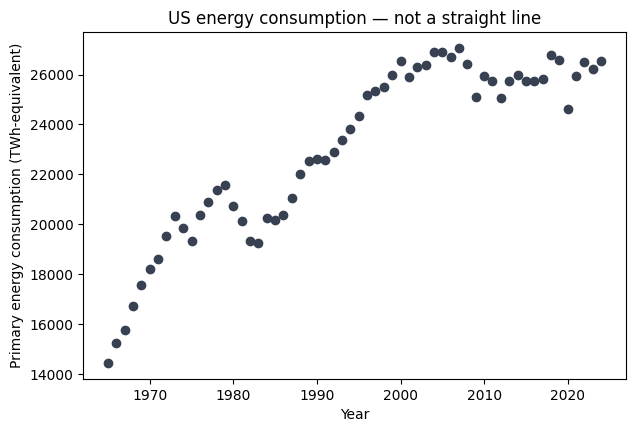

In [39]:
ENERGY_URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
ENERGY_PATH = "data/us-energy-consumption.csv"

if not os.path.exists(ENERGY_PATH):
    energy_df = pd.read_csv(ENERGY_URL)
    us_energy = energy_df[energy_df['country'] == 'United States'][['year', 'primary_energy_consumption']].dropna()
    us_energy.to_csv(ENERGY_PATH, index=False)

energy = pd.read_csv(ENERGY_PATH).reset_index(drop=True)
plt.figure(figsize=(7, 4.5))
plt.scatter(energy['year'], energy['primary_energy_consumption'], color="#374151")
plt.xlabel("Year"); plt.ylabel("Primary energy consumption (TWh-equivalent)")
plt.title("US energy consumption — not a straight line")
plt.show()

In [40]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn import metrics

# every 5th point held out as the test set, matching the class's split strategy
size = len(energy.index)
test_idx = range(0, size, 5)
train = energy[~energy.index.isin(test_idx)]
test = energy[energy.index.isin(test_idx)]

X_train_e = train['year'].values.reshape(-1, 1)
y_train_e = train['primary_energy_consumption']
X_test_e = test['year'].values.reshape(-1, 1)
y_test_e = test['primary_energy_consumption']

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 48 rows | Test: 12 rows


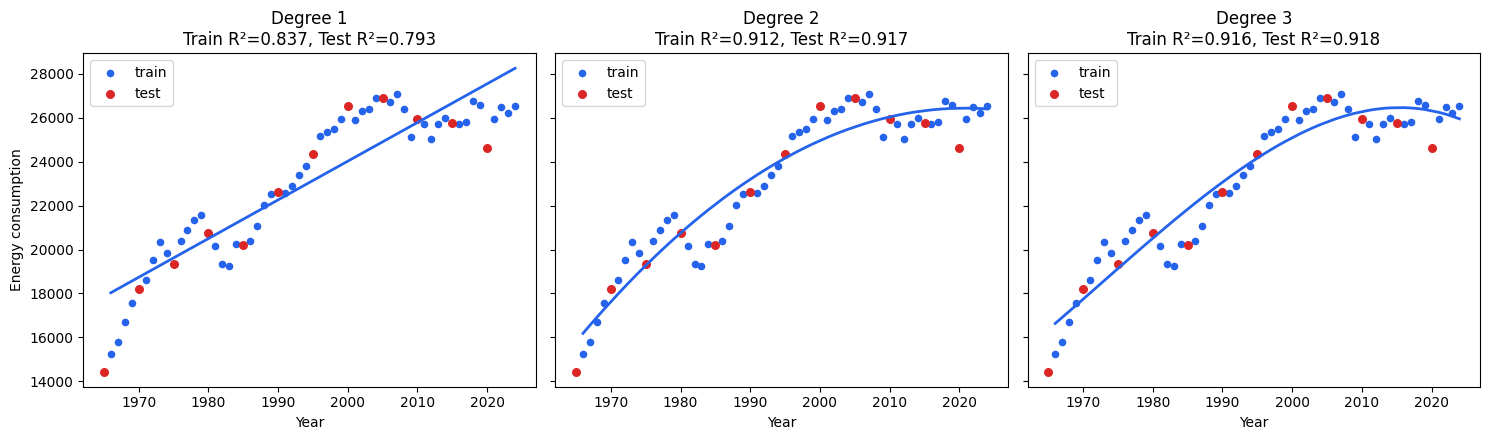

Degree 1: Train R² = 0.837, Test R² = 0.793
Degree 2: Train R² = 0.912, Test R² = 0.917
Degree 3: Train R² = 0.916, Test R² = 0.918


In [41]:
degrees = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
r2_train, r2_test = [], []

for ax, degree in zip(axes, degrees):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('model', LinearRegression())
    ])
    pipeline.fit(X_train_e, y_train_e)

    tr = metrics.r2_score(y_train_e, pipeline.predict(X_train_e))
    te = metrics.r2_score(y_test_e, pipeline.predict(X_test_e))
    r2_train.append(tr); r2_test.append(te)

    order = np.argsort(X_train_e.flatten())
    ax.scatter(X_train_e, y_train_e, color="#2563EB", s=20, label="train")
    ax.plot(X_train_e[order], pipeline.predict(X_train_e)[order], color="#2563EB", lw=2)
    ax.scatter(X_test_e, y_test_e, color="#DC2626", s=30, label="test")
    ax.set_title(f"Degree {degree}\nTrain R²={tr:.3f}, Test R²={te:.3f}")
    ax.set_xlabel("Year")
    ax.legend()

axes[0].set_ylabel("Energy consumption")
plt.tight_layout()
plt.show()

for d, tr, te in zip(degrees, r2_train, r2_test):
    print(f"Degree {d}: Train R² = {tr:.3f}, Test R² = {te:.3f}")

Degree 1 clearly misses the curvature — both R² scores land noticeably lower than degree 2. Degree 2 captures
the bend well. Degree 3 barely improves on degree 2 at all — extra complexity with nothing to show for it.

> **Lesson:** always evaluate on held-out test data to pick the degree. Here, degree 2 is the sweet spot;
> pushing further would start trading real fit for overfitting, which is exactly what the next section names.


## 22. The Bias-Variance Tradeoff

One of the most fundamental ideas in all of machine learning — every model balances two competing failure modes.

**The student analogy:**

| | 😴 The under-studier (underfitting) | 🎓 The over-studier (overfitting) |
|---|---|---|
| What they did | Skimmed chapter headings | Memorized every practice question |
| Practice problems | Can't answer them | Perfect score |
| The real exam (new questions) | Fails | Fails — new phrasing throws them off |
| Train score | Low | High |
| Test score | Low | Low |

| Scenario | Train R² | Test R² | Problem |
|---|---|---|---|
| Underfitting | Low | Low | Model too simple — misses the real pattern |
| Overfitting | High | Low | Model too complex — memorized training noise |
| Just right | Good | Good | Generalizes to new data |

**In bias/variance terms:**

- **High bias, low variance** — consistently misses in the same wrong direction. Underfitting.
- **Low bias, high variance** — aims correctly on average but scatters wildly run to run. Overfitting.
- **Low bias, low variance** — the goal.
- **High bias, high variance** — the worst case, both problems compounding.


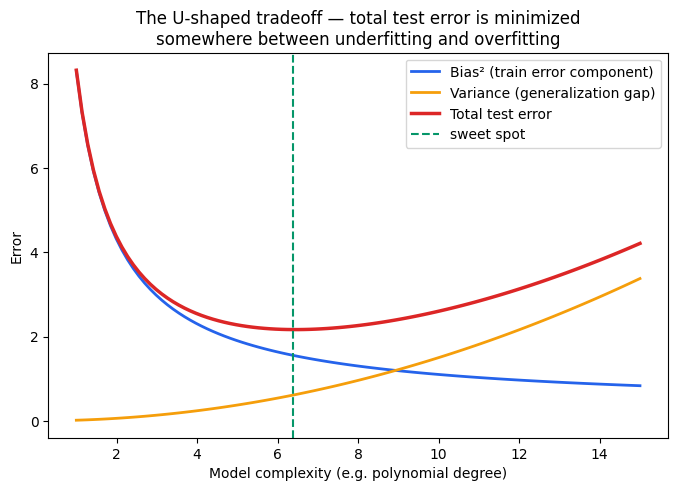

In [42]:
complexity = np.linspace(1, 15, 100)
bias_sq = 8 / complexity + 0.3
variance = 0.015 * complexity**2
total_error = bias_sq + variance

best_idx = np.argmin(total_error)

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias_sq, color="#2563EB", lw=2, label="Bias² (train error component)")
plt.plot(complexity, variance, color="#F59E0B", lw=2, label="Variance (generalization gap)")
plt.plot(complexity, total_error, color="#DC2626", lw=2.5, label="Total test error")
plt.axvline(complexity[best_idx], color="#059669", ls="--", lw=1.5, label="sweet spot")
plt.xlabel("Model complexity (e.g. polynomial degree)")
plt.ylabel("Error")
plt.title("The U-shaped tradeoff — total test error is minimized\nsomewhere between underfitting and overfitting")
plt.legend()
plt.show()

**Connecting this to polynomial degree specifically** — a model $\hat{y} = w_0 + w_1x + w_2x^2 + w_3x^3 + w_4x^4$:

| Model | Non-zero weights | Complexity | Risk |
|---|---|---|---|
| Highest-degree | all of $w_1 \ldots w_4$ | highest | overfitting |
| Balanced | $w_1, w_2$ only | medium | — |
| Degree 1 | $w_1$ only | lowest | underfitting |

The more non-zero higher-order weights a model is allowed, the more it can contort itself to fit the training
data exactly — which is precisely what drives variance up and risks memorizing noise instead of the real trend.
This is exactly the degree-1-vs-2-vs-3 comparison from Section 21, generalized to any model.

> **The goal:** find the complexity where both train and test error are acceptably low — the generalization
> sweet spot where the model has learned the real pattern, not the noise.


## 23. Summary — revision cheat sheet

**The model:** $y = m_1x_1 + m_2x_2 + \cdots + c$ — a straight line (one feature) or a hyperplane (two or more
features) fit through the data. Every ML algorithm reduces to the same three ingredients: **Model** (predicts),
**Cost Function** (scores the error), **Optimizer** (reduces it).

**Fitting it — the loop:** start with random $m$, $c$ → predict → measure error with MSE → nudge $m$, $c$ downhill
via gradient descent → repeat until the error stops meaningfully improving.

**Core definitions:**
- *MSE (the cost function)* — $\frac{1}{n}\sum(y - y_{predicted})^2$; convex, so it has a single global minimum
  and gradient descent always finds it.
- *Gradient descent (the optimizer)* — repeatedly step each parameter opposite its gradient:
  $x = x - \text{learning_rate} \cdot \frac{d(Error)}{dx}$.
- *R² (coefficient of determination)* — $1 - RSS/TSS$; how much better your model does than just predicting the
  mean every time. Range $(-\infty, 1]$; near 1 is a great fit, near 0 is no better than the mean, negative is
  worse than the mean.
- *Adjusted R²* — $R^2$ penalized for feature count; the fair way to compare models with different numbers of
  features, since plain $R^2$ never decreases from adding *any* feature, useful or not.
- *Feature scaling* — Z-score standardization $(x-\mu)/\sigma$ or Min-Max $(x-\min)/(\max-\min)$; makes
  coefficients comparable and helps gradient descent converge. Min-Max is outlier-sensitive; standardization is
  the safer default.

**Preprocessing checklist, built up across this notebook:**
- Split into train/test *before* fitting, and never let the model see test data during training.
- One-hot encode categorical features (dropping one column to avoid redundancy).
- Impute missing values with the median (robust to skew/outliers) rather than the mean.
- Detect and treat outliers — squared error means a single extreme point can drag the whole line off course.

**Trusting the model — the 5 assumptions:**
1. Linearity — fix with Polynomial Regression if violated.
2. No multicollinearity — detect with VIF ($1/(1-R_j^2)$), fix by removing high-VIF features.
3. Normal residuals — check with a histogram + Shapiro-Wilk.
4. Independent errors — check with Durbin-Watson (≈2.0 is healthy).
5. Homoscedasticity — check visually (residuals vs. predicted) and with the Goldfeld-Quandt test.

**Generalization — the Bias-Variance Tradeoff:** too simple underfits (high bias, low variance, poor on both
train and test); too complex overfits (low bias, high variance, great on train, poor on test). The right model
complexity minimizes total test error, not train error.

**Next up:** Regularization (Ridge / Lasso — penalizing large weights directly, rather than manually removing
features) and Cross-Validation (a more robust way to pick that model complexity than a single train/test split).
